# 03 — Multi-Model EOR Classification Benchmark

This notebook is the model-comparison authority for the EOR research layer.

In [8]:
import inspect
from notebook_utils import standardize_training_table

print(inspect.getsource(standardize_training_table))

def standardize_training_table(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    for name, aliases in COLUMN_ALIASES.items():
        source = find_column(df, aliases)
        if source is not None:
            out[name] = df[source]

    required = [
        "technique", "formation",
        "depth_min", "depth_max", "por_min", "por_max",
        "perm_min", "perm_max", "api_min", "api_max",
        "visc_min", "visc_max", "so_min", "so_max",
    ]
    missing = [c for c in required if c not in out.columns]
    if missing:
        raise ValueError(f"Missing required fields: {missing}")

    for c in required:
        if c not in {"technique", "formation"}:
            out[c] = pd.to_numeric(out[c], errors="coerce")

    out["technique"] = out["technique"].astype(str).str.strip()
    out["formation"] = out["formation"].astype(str).str.strip().replace({
        "Carbonate": "Carbonates",
        "Unconsolidated Sand": "Unconsolidated sands",
    })

    out =

In [10]:
import sys
from pathlib import Path
NB_DIR = Path.cwd()
if not (NB_DIR / 'notebook_utils.py').exists():
    NB_DIR = next(p for p in [NB_DIR, *NB_DIR.parents] if (p / 'src' / 'notebooks' / 'notebook_utils.py').exists()) / 'src' / 'notebooks'
sys.path.insert(0, str(NB_DIR))

from notebook_utils import *

In [11]:
raw_df, chosen = select_training_table()
df = standardize_training_table(raw_df)
X, y_text, FEATURE_NAMES = build_feature_table(df)
le = LabelEncoder()
y = le.fit_transform(y_text)
print('Selected:', chosen)
print('Rows:', len(df))
print('Classes:', list(le.classes_))
display(y_text.value_counts().rename('count').to_frame())

Selected: {'path': 'c:\\Users\\mnabielizzuddin.radz\\OneDrive - PETRONAS\\Reservoir Engineering\\Programming_Python_Projects\\EOR ATLAS\\EORWEB\\EORWEBDEV\\src\\notebooks\\ml_data\\OGJ2014_extracted_vs_Table1.xlsx', 'sheet': 'OGJ2014_Extracted_Rows', 'rows': 624, 'columns': 15, 'target_column': 'technique', 'formation_column': 'formation_category', 'range_column_hits': 12}
Rows: 526
Classes: ['Combustion', 'HC immiscible', 'Hot water', 'Miscible CO2', 'Miscible HC', 'Miscible acid gas', 'Nitrogen immiscible', 'Polymer', 'Steam']


,count
technique,
Miscible CO2,173
Polymer,117
Miscible HC,105
Steam,92
Combustion,24
Nitrogen immiscible,7
Hot water,4
HC immiscible,2
Miscible acid gas,2


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
results, fitted_models = benchmark_models(X_train, y_train, X_test, y_test, le)
display(results)


=== LogisticRegression ===


c:\Users\mnabielizzuddin.radz\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\mnabielizzuddin.radz\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\mnabielizzuddin.radz\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(



=== SVM_RBF ===


c:\Users\mnabielizzuddin.radz\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



=== KNN ===


...


=== XGBoost ===


c:\Users\mnabielizzuddin.radz\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(



=== CatBoost ===


c:\Users\mnabielizzuddin.radz\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


,Model,CV_MacroF1,Test_BalancedAccuracy,Test_MacroF1,Test_WeightedF1,Test_MCC,Test_LogLoss,Test_Top3
0,KNN,0.799016,0.889724,0.892782,0.823422,0.779606,5.157536,0.858491
1,CatBoost,0.785281,0.881561,0.883931,0.806826,0.753560,0.642572,0.990566
2,XGBoost,0.779124,0.881561,0.883931,0.806826,0.753560,0.881678,0.990566
3,HistGradientBoosting,0.773699,0.881561,0.883931,0.806826,0.753560,0.604771,0.990566
4,RandomForest,0.769695,0.863364,0.866234,0.774745,0.703918,0.489827,0.990566
5,ExtraTrees,0.797345,0.884998,0.841741,0.809555,0.753856,0.473975,1.000000
6,SVM_RBF,0.794146,0.741497,0.738056,0.786836,0.728191,0.500662,1.000000
7,LogisticRegression,0.626355,0.664313,0.533854,0.694098,0.587487,1.491071,0.943396
8,MLP,0.342102,0.368895,0.354159,0.597820,0.546451,1.387468,0.886792


EOR ATLAS — MODEL-BY-MODEL PREDICTION & EVALUATION

Total test observations : 106
Total EOR classes      : 9
Classes                : ['Combustion', 'HC immiscible', 'Hot water', 'Miscible CO2', 'Miscible HC', 'Miscible acid gas', 'Nitrogen immiscible', 'Polymer', 'Steam']


MODEL: LogisticRegression

--- ACTUAL vs PREDICTED ---


,Actual_Code,Actual,Predicted_Code,Predicted,Correct,Result
0,8,Steam,8,Steam,True,✓ Correct
1,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
2,4,Miscible HC,4,Miscible HC,True,✓ Correct
3,3,Miscible CO2,3,Miscible CO2,True,✓ Correct
4,8,Steam,8,Steam,True,✓ Correct
...,...,...,...,...,...,...
101,4,Miscible HC,0,Combustion,False,✗ Wrong
102,4,Miscible HC,4,Miscible HC,True,✓ Correct
103,4,Miscible HC,6,Nitrogen immiscible,False,✗ Wrong
104,3,Miscible CO2,4,Miscible HC,False,✗ Wrong



--- OVERALL MODEL SCORES ---


c:\Users\mnabielizzuddin.radz\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,Metric,Score
0,Accuracy,0.6698
1,Balanced Accuracy,0.6643
2,Macro F1,0.4745
3,MCC,0.5875
4,Log Loss,1.4911



--- CLASSIFICATION REPORT ---


,precision,recall,f1-score,support
Combustion,0.714,1.000,0.833,5
HC immiscible,0.000,0.000,0.000,0
Hot water,0.500,1.000,0.667,1
Miscible CO2,0.759,0.629,0.688,35
Miscible HC,0.524,0.524,0.524,21
Miscible acid gas,0.000,0.000,0.000,0
Nitrogen immiscible,0.000,0.000,0.000,1
Polymer,0.944,0.708,0.810,24
Steam,0.714,0.789,0.750,19
accuracy,0.670,0.670,0.670,1



--- CONFUSION MATRIX ---


,Combustion,HC immiscible,Hot water,Miscible CO2,Miscible HC,Miscible acid gas,Nitrogen immiscible,Polymer,Steam
Combustion,5,0,0,0,0,0,0,0,0
HC immiscible,0,0,0,0,0,0,0,0,0
Hot water,0,0,1,0,0,0,0,0,0
Miscible CO2,1,0,0,22,7,0,5,0,0
Miscible HC,1,1,0,6,11,0,2,0,0
Miscible acid gas,0,0,0,0,0,0,0,0,0
Nitrogen immiscible,0,0,0,1,0,0,0,0,0
Polymer,0,0,0,0,1,0,0,17,6
Steam,0,0,1,0,2,0,0,1,15


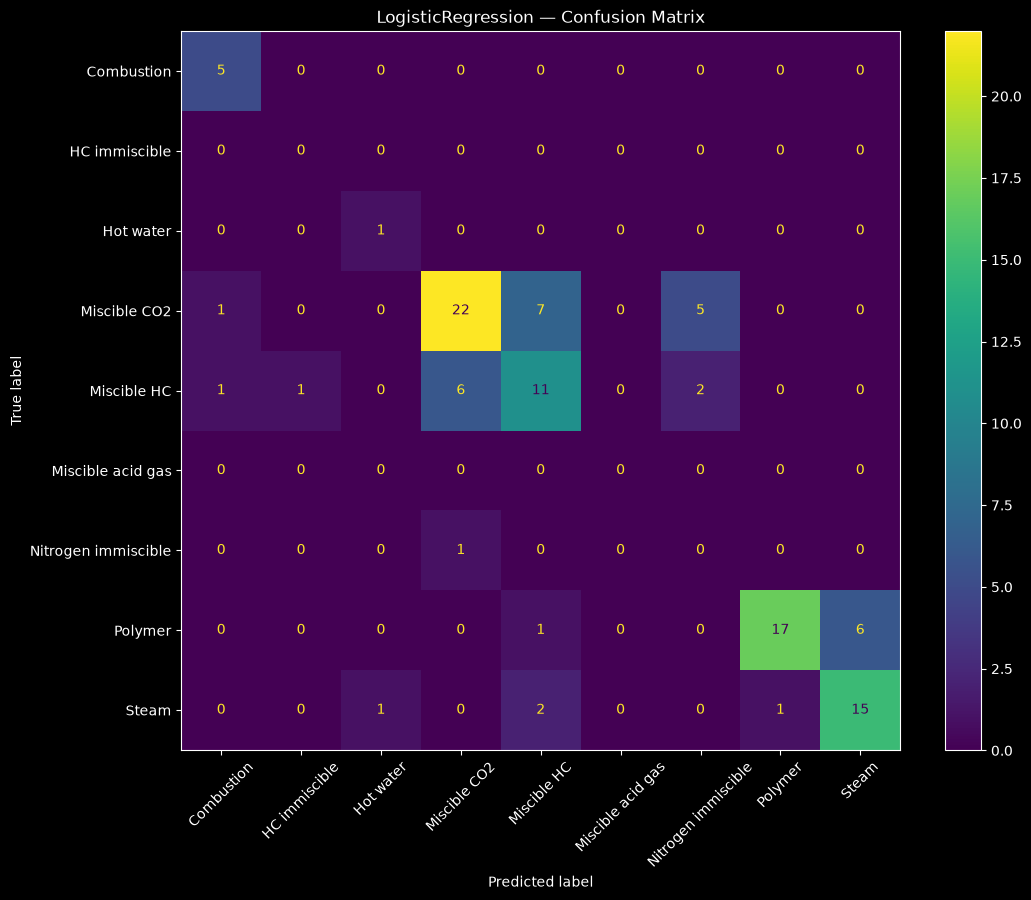



MODEL: SVM_RBF

--- ACTUAL vs PREDICTED ---


,Actual_Code,Actual,Predicted_Code,Predicted,Correct,Result
0,8,Steam,8,Steam,True,✓ Correct
1,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
2,4,Miscible HC,4,Miscible HC,True,✓ Correct
3,3,Miscible CO2,3,Miscible CO2,True,✓ Correct
4,8,Steam,8,Steam,True,✓ Correct
...,...,...,...,...,...,...
101,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
102,4,Miscible HC,4,Miscible HC,True,✓ Correct
103,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
104,3,Miscible CO2,3,Miscible CO2,True,✓ Correct



--- OVERALL MODEL SCORES ---


,Metric,Score
0,Accuracy,0.7642
1,Balanced Accuracy,0.8646
2,Macro F1,0.6379
3,MCC,0.6941
4,Log Loss,0.5007



--- CLASSIFICATION REPORT ---


,precision,recall,f1-score,support
Combustion,1.000,1.000,1.000,5
HC immiscible,0.000,0.000,0.000,0
Hot water,0.500,1.000,0.667,1
Miscible CO2,0.667,0.629,0.647,35
Miscible HC,0.435,0.476,0.455,21
Miscible acid gas,0.000,0.000,0.000,0
Nitrogen immiscible,1.000,1.000,1.000,1
Polymer,1.000,1.000,1.000,24
Steam,1.000,0.947,0.973,19
accuracy,0.764,0.764,0.764,1



--- CONFUSION MATRIX ---


,Combustion,HC immiscible,Hot water,Miscible CO2,Miscible HC,Miscible acid gas,Nitrogen immiscible,Polymer,Steam
Combustion,5,0,0,0,0,0,0,0,0
HC immiscible,0,0,0,0,0,0,0,0,0
Hot water,0,0,1,0,0,0,0,0,0
Miscible CO2,0,0,0,22,13,0,0,0,0
Miscible HC,0,0,0,11,10,0,0,0,0
Miscible acid gas,0,0,0,0,0,0,0,0,0
Nitrogen immiscible,0,0,0,0,0,0,1,0,0
Polymer,0,0,0,0,0,0,0,24,0
Steam,0,0,1,0,0,0,0,0,18


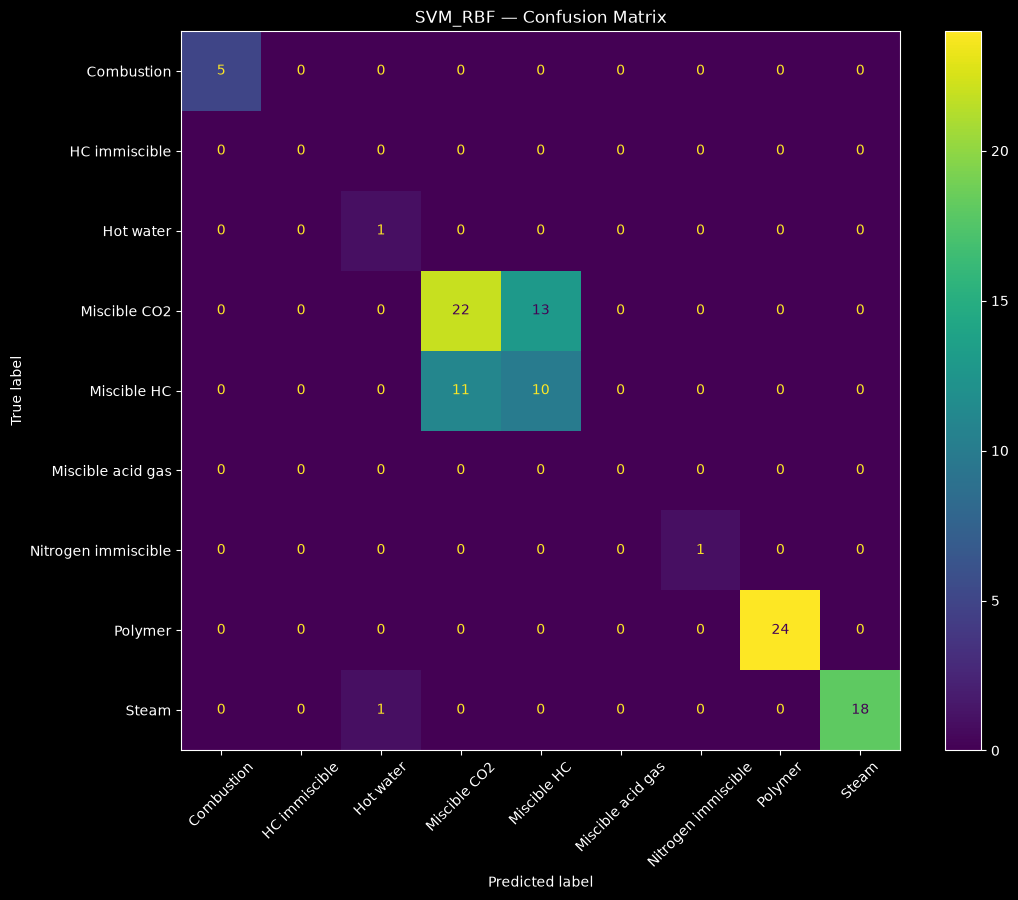



MODEL: KNN

--- ACTUAL vs PREDICTED ---


,Actual_Code,Actual,Predicted_Code,Predicted,Correct,Result
0,8,Steam,8,Steam,True,✓ Correct
1,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
2,4,Miscible HC,4,Miscible HC,True,✓ Correct
3,3,Miscible CO2,3,Miscible CO2,True,✓ Correct
4,8,Steam,8,Steam,True,✓ Correct
...,...,...,...,...,...,...
101,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
102,4,Miscible HC,4,Miscible HC,True,✓ Correct
103,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
104,3,Miscible CO2,3,Miscible CO2,True,✓ Correct



--- OVERALL MODEL SCORES ---


,Metric,Score
0,Accuracy,0.8302
1,Balanced Accuracy,0.8897
2,Macro F1,0.6944
3,MCC,0.7796
4,Log Loss,5.1575



--- CLASSIFICATION REPORT ---


,precision,recall,f1-score,support
Combustion,1.000,1.000,1.000,5
HC immiscible,0.000,0.000,0.000,0
Hot water,1.000,1.000,1.000,1
Miscible CO2,0.732,0.857,0.789,35
Miscible HC,0.667,0.476,0.556,21
Miscible acid gas,0.000,0.000,0.000,0
Nitrogen immiscible,1.000,1.000,1.000,1
Polymer,0.923,1.000,0.960,24
Steam,1.000,0.895,0.944,19
accuracy,0.830,0.830,0.830,1



--- CONFUSION MATRIX ---


,Combustion,HC immiscible,Hot water,Miscible CO2,Miscible HC,Miscible acid gas,Nitrogen immiscible,Polymer,Steam
Combustion,5,0,0,0,0,0,0,0,0
HC immiscible,0,0,0,0,0,0,0,0,0
Hot water,0,0,1,0,0,0,0,0,0
Miscible CO2,0,0,0,30,5,0,0,0,0
Miscible HC,0,0,0,11,10,0,0,0,0
Miscible acid gas,0,0,0,0,0,0,0,0,0
Nitrogen immiscible,0,0,0,0,0,0,1,0,0
Polymer,0,0,0,0,0,0,0,24,0
Steam,0,0,0,0,0,0,0,2,17


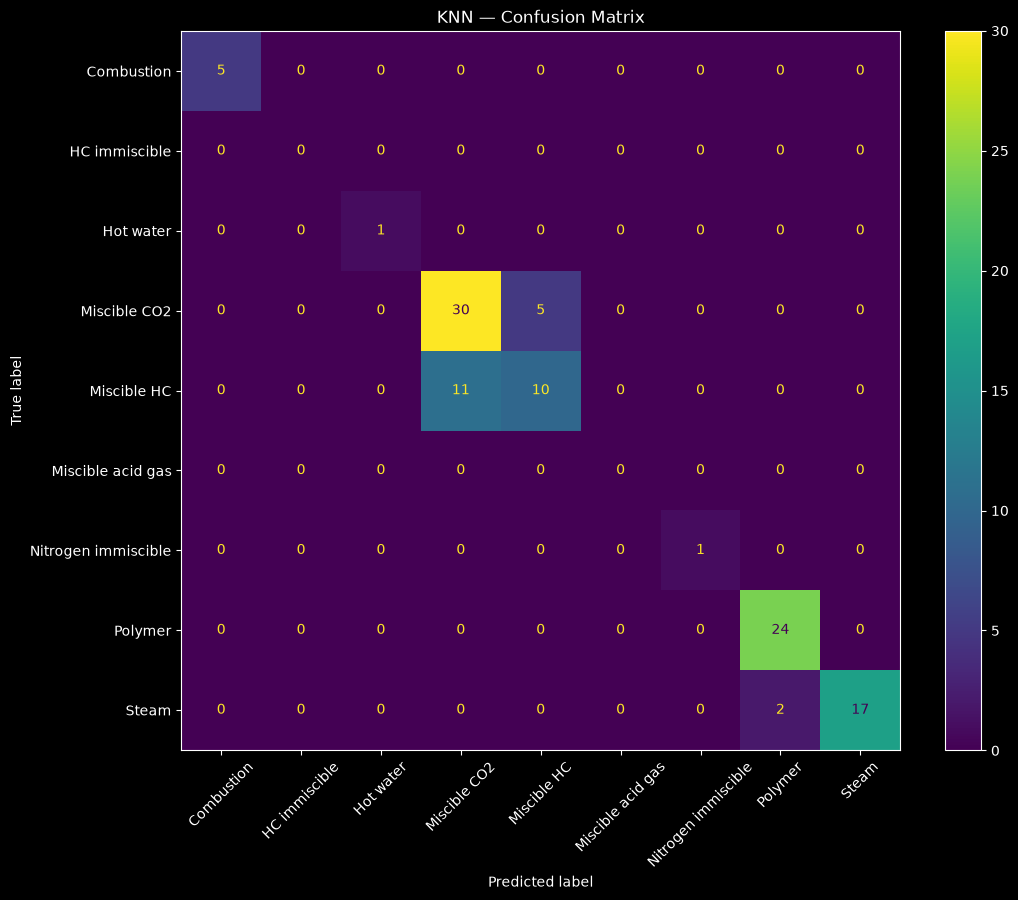



MODEL: RandomForest

--- ACTUAL vs PREDICTED ---


,Actual_Code,Actual,Predicted_Code,Predicted,Correct,Result
0,8,Steam,8,Steam,True,✓ Correct
1,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
2,4,Miscible HC,4,Miscible HC,True,✓ Correct
3,3,Miscible CO2,3,Miscible CO2,True,✓ Correct
4,8,Steam,8,Steam,True,✓ Correct
...,...,...,...,...,...,...
101,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
102,4,Miscible HC,4,Miscible HC,True,✓ Correct
103,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
104,3,Miscible CO2,3,Miscible CO2,True,✓ Correct



--- OVERALL MODEL SCORES ---


,Metric,Score
0,Accuracy,0.7736
1,Balanced Accuracy,0.8634
2,Macro F1,0.6737
3,MCC,0.7039
4,Log Loss,0.4898



--- CLASSIFICATION REPORT ---


,precision,recall,f1-score,support
Combustion,1.000,1.000,1.000,5
HC immiscible,0.000,0.000,0.000,0
Hot water,1.000,1.000,1.000,1
Miscible CO2,0.694,0.714,0.704,35
Miscible HC,0.476,0.476,0.476,21
Miscible acid gas,0.000,0.000,0.000,0
Nitrogen immiscible,1.000,1.000,1.000,1
Polymer,0.920,0.958,0.939,24
Steam,1.000,0.895,0.944,19
accuracy,0.774,0.774,0.774,1



--- CONFUSION MATRIX ---


,Combustion,HC immiscible,Hot water,Miscible CO2,Miscible HC,Miscible acid gas,Nitrogen immiscible,Polymer,Steam
Combustion,5,0,0,0,0,0,0,0,0
HC immiscible,0,0,0,0,0,0,0,0,0
Hot water,0,0,1,0,0,0,0,0,0
Miscible CO2,0,0,0,25,10,0,0,0,0
Miscible HC,0,0,0,11,10,0,0,0,0
Miscible acid gas,0,0,0,0,0,0,0,0,0
Nitrogen immiscible,0,0,0,0,0,0,1,0,0
Polymer,0,0,0,0,1,0,0,23,0
Steam,0,0,0,0,0,0,0,2,17


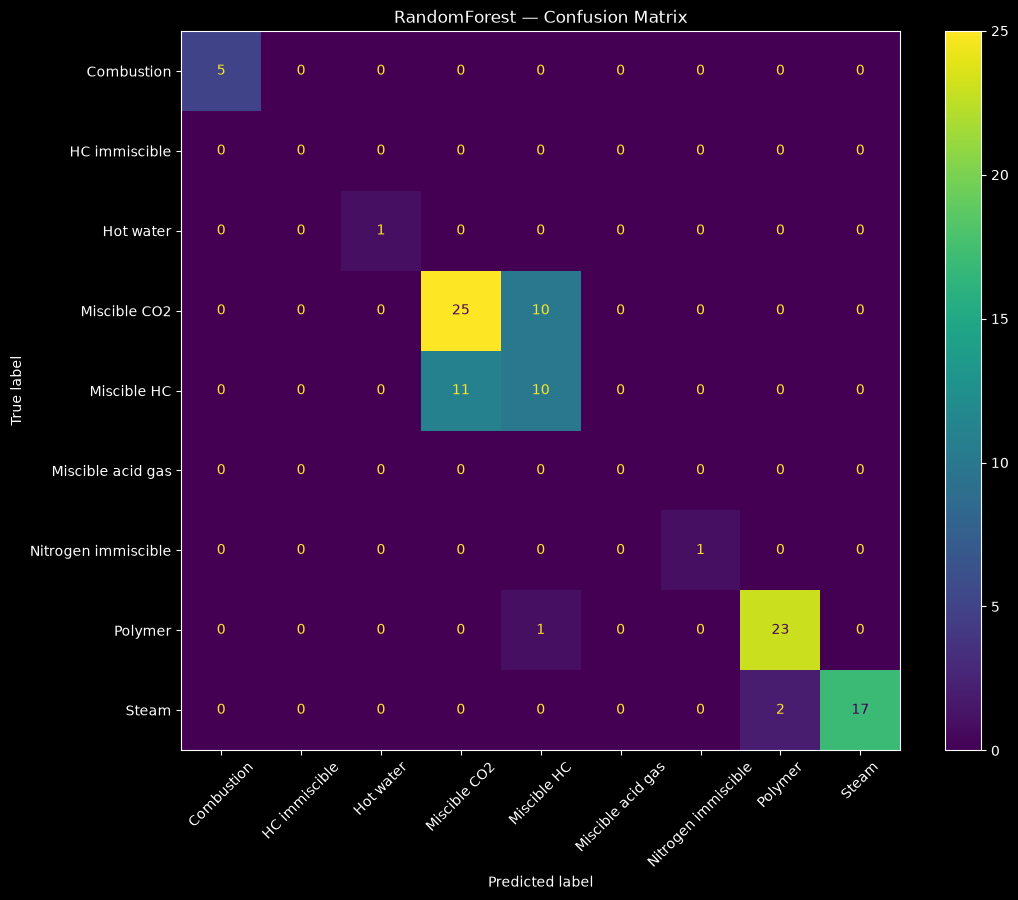



MODEL: ExtraTrees

--- ACTUAL vs PREDICTED ---


,Actual_Code,Actual,Predicted_Code,Predicted,Correct,Result
0,8,Steam,8,Steam,True,✓ Correct
1,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
2,4,Miscible HC,4,Miscible HC,True,✓ Correct
3,3,Miscible CO2,3,Miscible CO2,True,✓ Correct
4,8,Steam,8,Steam,True,✓ Correct
...,...,...,...,...,...,...
101,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
102,4,Miscible HC,4,Miscible HC,True,✓ Correct
103,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
104,3,Miscible CO2,3,Miscible CO2,True,✓ Correct



--- OVERALL MODEL SCORES ---


,Metric,Score
0,Accuracy,0.8113
1,Balanced Accuracy,0.8850
2,Macro F1,0.6547
3,MCC,0.7539
4,Log Loss,0.4740



--- CLASSIFICATION REPORT ---


,precision,recall,f1-score,support
Combustion,1.000,1.000,1.000,5
HC immiscible,0.000,0.000,0.000,0
Hot water,0.500,1.000,0.667,1
Miscible CO2,0.711,0.771,0.740,35
Miscible HC,0.556,0.476,0.513,21
Miscible acid gas,0.000,0.000,0.000,0
Nitrogen immiscible,1.000,1.000,1.000,1
Polymer,1.000,1.000,1.000,24
Steam,1.000,0.947,0.973,19
accuracy,0.811,0.811,0.811,1



--- CONFUSION MATRIX ---


,Combustion,HC immiscible,Hot water,Miscible CO2,Miscible HC,Miscible acid gas,Nitrogen immiscible,Polymer,Steam
Combustion,5,0,0,0,0,0,0,0,0
HC immiscible,0,0,0,0,0,0,0,0,0
Hot water,0,0,1,0,0,0,0,0,0
Miscible CO2,0,0,0,27,8,0,0,0,0
Miscible HC,0,0,0,11,10,0,0,0,0
Miscible acid gas,0,0,0,0,0,0,0,0,0
Nitrogen immiscible,0,0,0,0,0,0,1,0,0
Polymer,0,0,0,0,0,0,0,24,0
Steam,0,0,1,0,0,0,0,0,18


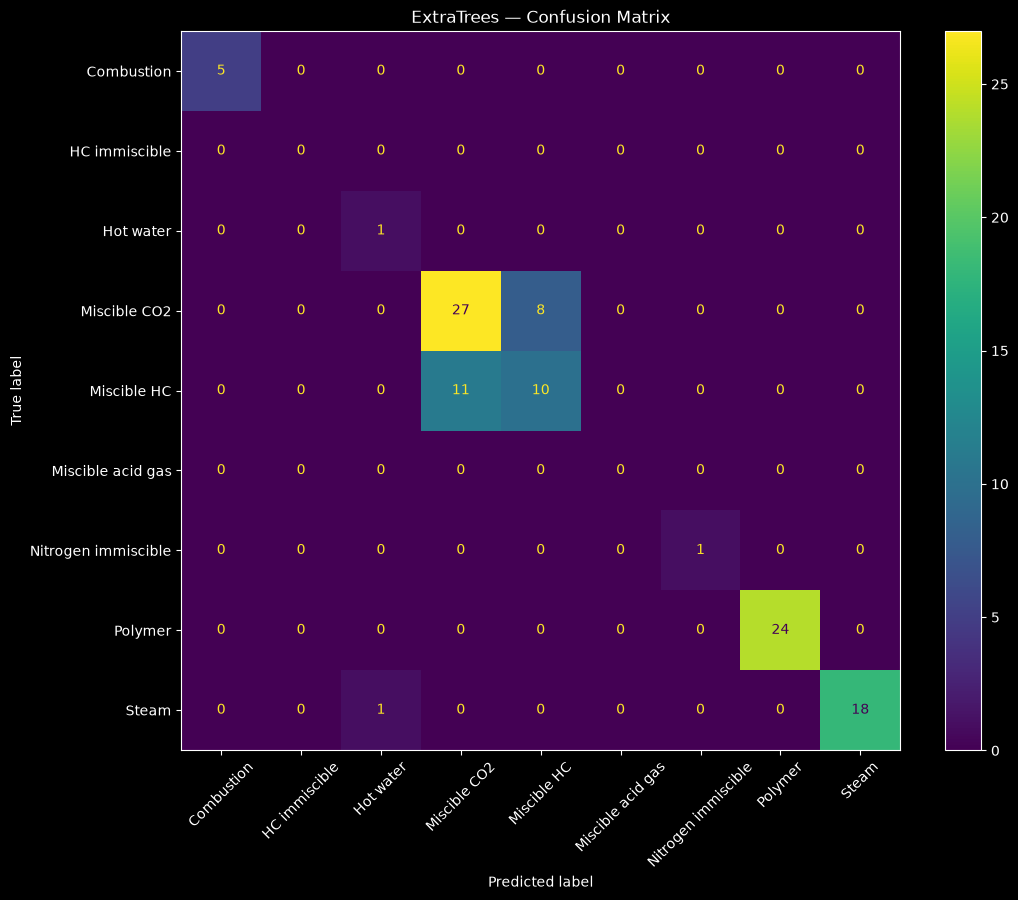



MODEL: HistGradientBoosting

--- ACTUAL vs PREDICTED ---


,Actual_Code,Actual,Predicted_Code,Predicted,Correct,Result
0,8,Steam,8,Steam,True,✓ Correct
1,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
2,4,Miscible HC,4,Miscible HC,True,✓ Correct
3,3,Miscible CO2,3,Miscible CO2,True,✓ Correct
4,8,Steam,8,Steam,True,✓ Correct
...,...,...,...,...,...,...
101,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
102,4,Miscible HC,4,Miscible HC,True,✓ Correct
103,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
104,3,Miscible CO2,3,Miscible CO2,True,✓ Correct



--- OVERALL MODEL SCORES ---


,Metric,Score
0,Accuracy,0.8113
1,Balanced Accuracy,0.8816
2,Macro F1,0.6875
3,MCC,0.7536
4,Log Loss,0.6048



--- CLASSIFICATION REPORT ---


,precision,recall,f1-score,support
Combustion,1.000,1.000,1.000,5
HC immiscible,0.000,0.000,0.000,0
Hot water,1.000,1.000,1.000,1
Miscible CO2,0.718,0.800,0.757,35
Miscible HC,0.588,0.476,0.526,21
Miscible acid gas,0.000,0.000,0.000,0
Nitrogen immiscible,1.000,1.000,1.000,1
Polymer,0.923,1.000,0.960,24
Steam,1.000,0.895,0.944,19
accuracy,0.811,0.811,0.811,1



--- CONFUSION MATRIX ---


,Combustion,HC immiscible,Hot water,Miscible CO2,Miscible HC,Miscible acid gas,Nitrogen immiscible,Polymer,Steam
Combustion,5,0,0,0,0,0,0,0,0
HC immiscible,0,0,0,0,0,0,0,0,0
Hot water,0,0,1,0,0,0,0,0,0
Miscible CO2,0,0,0,28,7,0,0,0,0
Miscible HC,0,0,0,11,10,0,0,0,0
Miscible acid gas,0,0,0,0,0,0,0,0,0
Nitrogen immiscible,0,0,0,0,0,0,1,0,0
Polymer,0,0,0,0,0,0,0,24,0
Steam,0,0,0,0,0,0,0,2,17


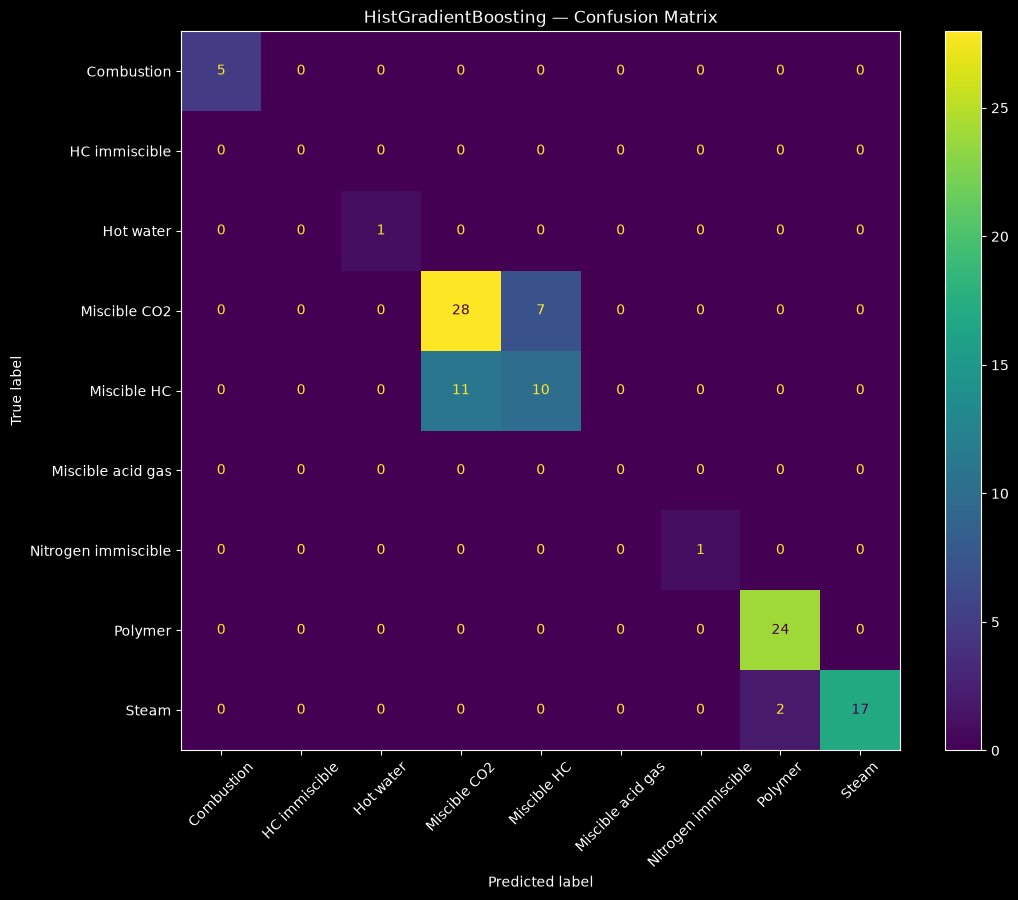



MODEL: MLP

--- ACTUAL vs PREDICTED ---


,Actual_Code,Actual,Predicted_Code,Predicted,Correct,Result
0,8,Steam,8,Steam,True,✓ Correct
1,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
2,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
3,3,Miscible CO2,3,Miscible CO2,True,✓ Correct
4,8,Steam,7,Polymer,False,✗ Wrong
...,...,...,...,...,...,...
101,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
102,4,Miscible HC,4,Miscible HC,True,✓ Correct
103,4,Miscible HC,7,Polymer,False,✗ Wrong
104,3,Miscible CO2,3,Miscible CO2,True,✓ Correct



--- OVERALL MODEL SCORES ---


,Metric,Score
0,Accuracy,0.6509
1,Balanced Accuracy,0.3689
2,Macro F1,0.2755
3,MCC,0.5465
4,Log Loss,1.3875



--- CLASSIFICATION REPORT ---


,precision,recall,f1-score,support
Combustion,0.000,0.000,0.000,5
HC immiscible,0.000,0.000,0.000,0
Hot water,0.000,0.000,0.000,1
Miscible CO2,0.600,0.943,0.733,35
Miscible HC,0.714,0.238,0.357,21
Miscible acid gas,0.000,0.000,0.000,0
Nitrogen immiscible,0.000,0.000,0.000,1
Polymer,0.677,0.875,0.764,24
Steam,0.769,0.526,0.625,19
accuracy,0.651,0.651,0.651,1



--- CONFUSION MATRIX ---


,Combustion,HC immiscible,Hot water,Miscible CO2,Miscible HC,Miscible acid gas,Nitrogen immiscible,Polymer,Steam
Combustion,0,0,0,4,1,0,0,0,0
HC immiscible,0,0,0,0,0,0,0,0,0
Hot water,0,0,0,0,0,0,0,0,1
Miscible CO2,0,0,0,33,1,0,0,1,0
Miscible HC,0,0,0,14,5,0,0,2,0
Miscible acid gas,0,0,0,0,0,0,0,0,0
Nitrogen immiscible,0,0,0,1,0,0,0,0,0
Polymer,0,0,0,1,0,0,0,21,2
Steam,0,0,0,2,0,0,0,7,10


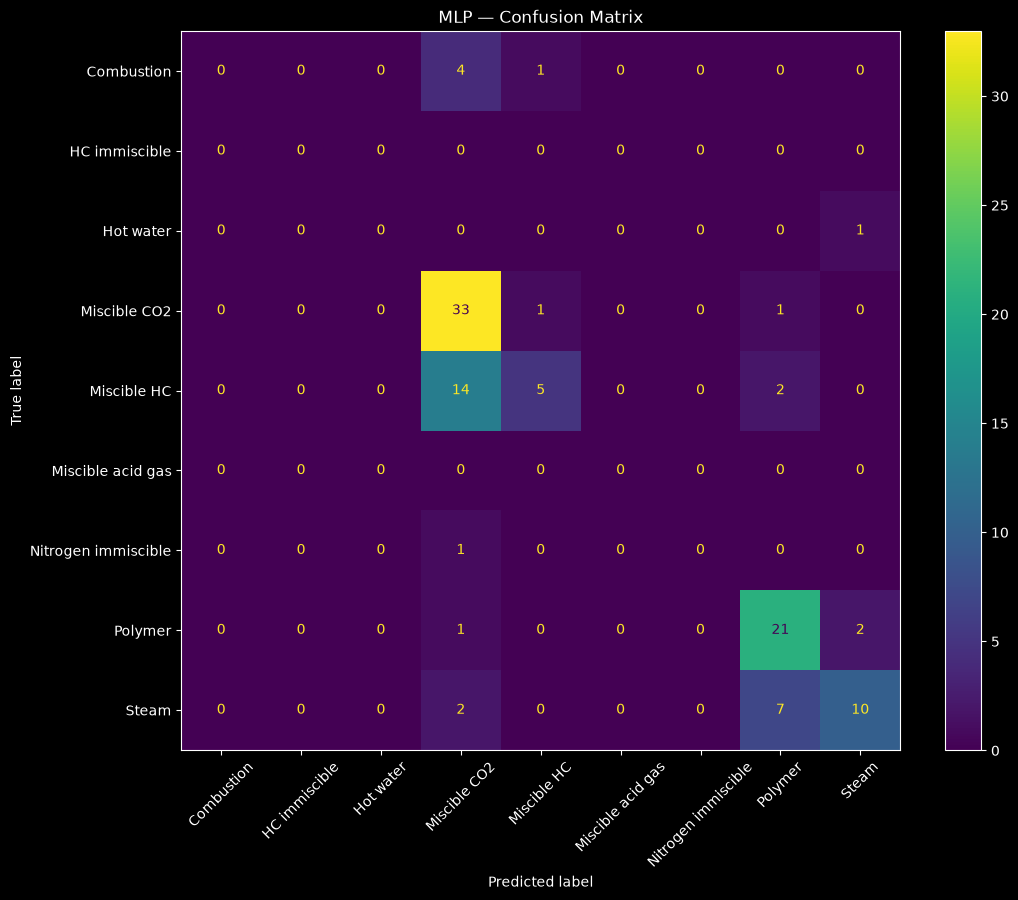



MODEL: XGBoost

--- ACTUAL vs PREDICTED ---


,Actual_Code,Actual,Predicted_Code,Predicted,Correct,Result
0,8,Steam,8,Steam,True,✓ Correct
1,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
2,4,Miscible HC,4,Miscible HC,True,✓ Correct
3,3,Miscible CO2,3,Miscible CO2,True,✓ Correct
4,8,Steam,8,Steam,True,✓ Correct
...,...,...,...,...,...,...
101,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
102,4,Miscible HC,4,Miscible HC,True,✓ Correct
103,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
104,3,Miscible CO2,3,Miscible CO2,True,✓ Correct



--- OVERALL MODEL SCORES ---


,Metric,Score
0,Accuracy,0.8113
1,Balanced Accuracy,0.8816
2,Macro F1,0.6875
3,MCC,0.7536
4,Log Loss,0.8817



--- CLASSIFICATION REPORT ---


,precision,recall,f1-score,support
Combustion,1.000,1.000,1.000,5
HC immiscible,0.000,0.000,0.000,0
Hot water,1.000,1.000,1.000,1
Miscible CO2,0.718,0.800,0.757,35
Miscible HC,0.588,0.476,0.526,21
Miscible acid gas,0.000,0.000,0.000,0
Nitrogen immiscible,1.000,1.000,1.000,1
Polymer,0.923,1.000,0.960,24
Steam,1.000,0.895,0.944,19
accuracy,0.811,0.811,0.811,1



--- CONFUSION MATRIX ---


,Combustion,HC immiscible,Hot water,Miscible CO2,Miscible HC,Miscible acid gas,Nitrogen immiscible,Polymer,Steam
Combustion,5,0,0,0,0,0,0,0,0
HC immiscible,0,0,0,0,0,0,0,0,0
Hot water,0,0,1,0,0,0,0,0,0
Miscible CO2,0,0,0,28,7,0,0,0,0
Miscible HC,0,0,0,11,10,0,0,0,0
Miscible acid gas,0,0,0,0,0,0,0,0,0
Nitrogen immiscible,0,0,0,0,0,0,1,0,0
Polymer,0,0,0,0,0,0,0,24,0
Steam,0,0,0,0,0,0,0,2,17


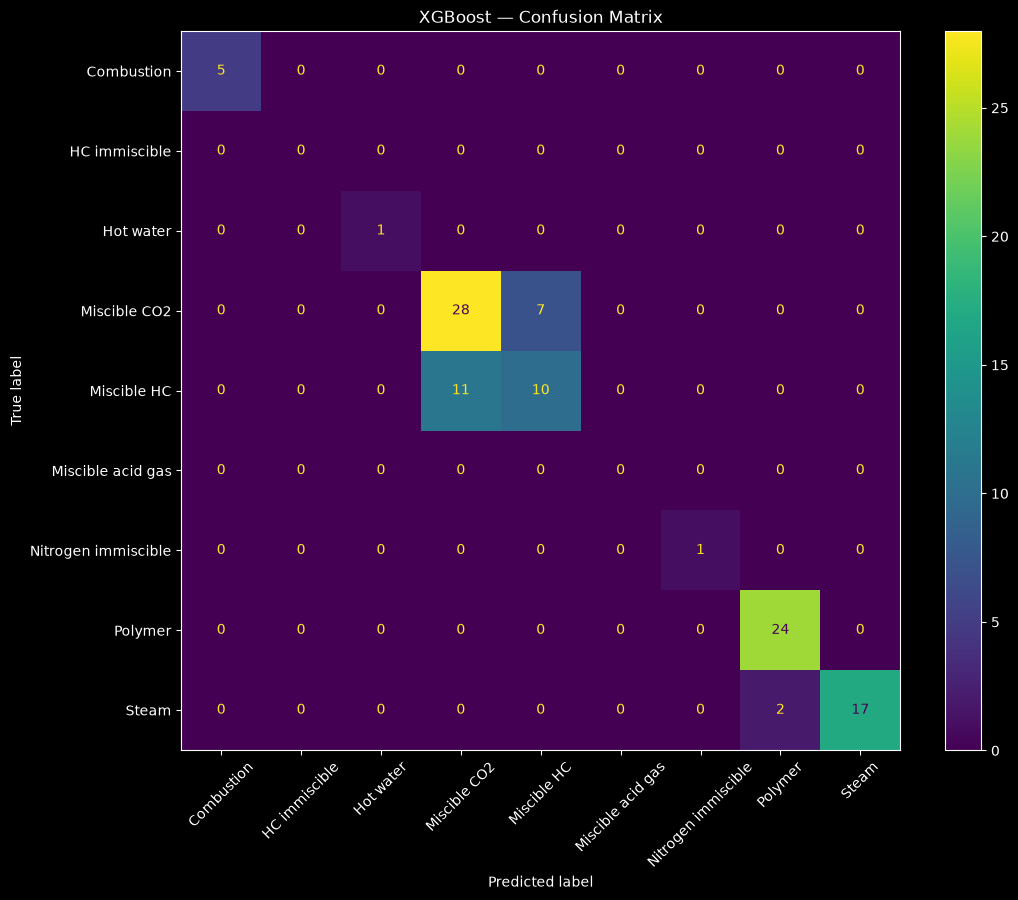



MODEL: CatBoost

--- ACTUAL vs PREDICTED ---


,Actual_Code,Actual,Predicted_Code,Predicted,Correct,Result
0,8,Steam,8,Steam,True,✓ Correct
1,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
2,4,Miscible HC,4,Miscible HC,True,✓ Correct
3,3,Miscible CO2,3,Miscible CO2,True,✓ Correct
4,8,Steam,8,Steam,True,✓ Correct
...,...,...,...,...,...,...
101,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
102,4,Miscible HC,4,Miscible HC,True,✓ Correct
103,4,Miscible HC,3,Miscible CO2,False,✗ Wrong
104,3,Miscible CO2,3,Miscible CO2,True,✓ Correct



--- OVERALL MODEL SCORES ---


,Metric,Score
0,Accuracy,0.8113
1,Balanced Accuracy,0.8816
2,Macro F1,0.6875
3,MCC,0.7536
4,Log Loss,0.6426



--- CLASSIFICATION REPORT ---


,precision,recall,f1-score,support
Combustion,1.000,1.000,1.000,5
HC immiscible,0.000,0.000,0.000,0
Hot water,1.000,1.000,1.000,1
Miscible CO2,0.718,0.800,0.757,35
Miscible HC,0.588,0.476,0.526,21
Miscible acid gas,0.000,0.000,0.000,0
Nitrogen immiscible,1.000,1.000,1.000,1
Polymer,0.923,1.000,0.960,24
Steam,1.000,0.895,0.944,19
accuracy,0.811,0.811,0.811,1



--- CONFUSION MATRIX ---


,Combustion,HC immiscible,Hot water,Miscible CO2,Miscible HC,Miscible acid gas,Nitrogen immiscible,Polymer,Steam
Combustion,5,0,0,0,0,0,0,0,0
HC immiscible,0,0,0,0,0,0,0,0,0
Hot water,0,0,1,0,0,0,0,0,0
Miscible CO2,0,0,0,28,7,0,0,0,0
Miscible HC,0,0,0,11,10,0,0,0,0
Miscible acid gas,0,0,0,0,0,0,0,0,0
Nitrogen immiscible,0,0,0,0,0,0,1,0,0
Polymer,0,0,0,0,0,0,0,24,0
Steam,0,0,0,0,0,0,0,2,17


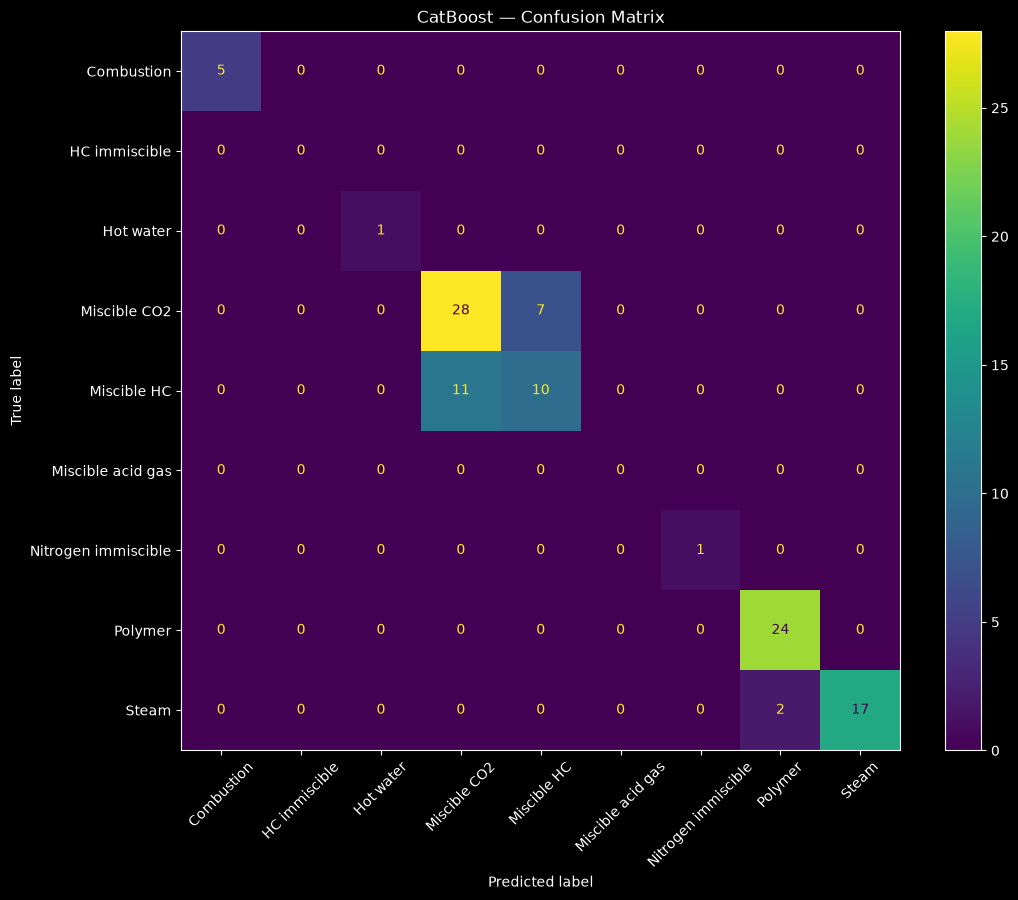



FINAL MODEL COMPARISON


,Model,Accuracy,Balanced Accuracy,Macro F1,MCC,Log Loss
0,KNN,0.8302,0.8897,0.6944,0.7796,5.1575
1,HistGradientBoosting,0.8113,0.8816,0.6875,0.7536,0.6048
2,XGBoost,0.8113,0.8816,0.6875,0.7536,0.8817
3,CatBoost,0.8113,0.8816,0.6875,0.7536,0.6426
4,RandomForest,0.7736,0.8634,0.6737,0.7039,0.4898
5,ExtraTrees,0.8113,0.8850,0.6547,0.7539,0.4740
6,SVM_RBF,0.7642,0.8646,0.6379,0.6941,0.5007
7,LogisticRegression,0.6698,0.6643,0.4745,0.5875,1.4911
8,MLP,0.6509,0.3689,0.2755,0.5465,1.3875


In [17]:
# ============================================================
# EOR ATLAS — COMPLETE MODEL EVALUATION
# Predict vs Actual + Scores + Confusion Matrix
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    log_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# ------------------------------------------------------------
# 1. GLOBAL CLASS SPACE
# ------------------------------------------------------------
# Keep the same class space for every model so comparisons
# remain consistent, even when some classes are absent in y_test.

all_labels = np.arange(len(le.classes_))

print("=" * 100)
print("EOR ATLAS — MODEL-BY-MODEL PREDICTION & EVALUATION")
print("=" * 100)

print(f"\nTotal test observations : {len(y_test)}")
print(f"Total EOR classes      : {len(le.classes_)}")
print(f"Classes                : {list(le.classes_)}")


# ------------------------------------------------------------
# 2. EVALUATE EVERY FITTED MODEL
# ------------------------------------------------------------
evaluation_summary = []

for model_name, model in fitted_models.items():

    print("\n")
    print("=" * 100)
    print(f"MODEL: {model_name}")
    print("=" * 100)

    try:
        # ----------------------------------------------------
        # PREDICTION
        # ----------------------------------------------------
        pred = model.predict(X_test)

        # Some estimators may return shape (n, 1)
        pred = np.asarray(pred).reshape(-1)

        # ----------------------------------------------------
        # PROBABILITY PREDICTION
        # ----------------------------------------------------
        proba = None

        if hasattr(model, "predict_proba"):
            try:
                proba = model.predict_proba(X_test)
            except Exception as e:
                print(f"\nProbability prediction unavailable: {e}")

        # ----------------------------------------------------
        # LABEL NORMALIZATION
        # ----------------------------------------------------
        # For classifiers trained using encoded integer labels,
        # predictions should already be integer class IDs.
        #
        # Convert safely in case a model returns numpy scalar types.
        pred_numeric = np.asarray(pred, dtype=int)

        # ----------------------------------------------------
        # ACTUAL VS PREDICTED TABLE
        # ----------------------------------------------------
        actual_labels = le.inverse_transform(np.asarray(y_test, dtype=int))
        predicted_labels = le.inverse_transform(pred_numeric)

        prediction_df = pd.DataFrame({
            "Actual_Code": np.asarray(y_test, dtype=int),
            "Actual": actual_labels,
            "Predicted_Code": pred_numeric,
            "Predicted": predicted_labels,
            "Correct": np.asarray(y_test, dtype=int) == pred_numeric,
        })

        prediction_df["Result"] = np.where(
            prediction_df["Correct"],
            "✓ Correct",
            "✗ Wrong"
        )

        print("\n--- ACTUAL vs PREDICTED ---")
        display(prediction_df)

        # ----------------------------------------------------
        # METRICS
        # ----------------------------------------------------
        accuracy = accuracy_score(y_test, pred_numeric)

        balanced_acc = balanced_accuracy_score(
            y_test,
            pred_numeric
        )

        macro_f1 = f1_score(
            y_test,
            pred_numeric,
            labels=all_labels,
            average="macro",
            zero_division=0,
        )

        mcc = matthews_corrcoef(
            y_test,
            pred_numeric
        )

        # Log loss if probabilities are available
        model_log_loss = np.nan

        if proba is not None:
            try:
                model_log_loss = log_loss(
                    y_test,
                    proba,
                    labels=all_labels
                )
            except Exception as e:
                print(f"\nLog Loss unavailable: {e}")

        print("\n--- OVERALL MODEL SCORES ---")

        score_df = pd.DataFrame({
            "Metric": [
                "Accuracy",
                "Balanced Accuracy",
                "Macro F1",
                "MCC",
                "Log Loss",
            ],
            "Score": [
                accuracy,
                balanced_acc,
                macro_f1,
                mcc,
                model_log_loss,
            ]
        })

        display(
            score_df.style.format({
                "Score": "{:.4f}"
            })
        )

        # ----------------------------------------------------
        # CLASSIFICATION REPORT
        # ----------------------------------------------------
        print("\n--- CLASSIFICATION REPORT ---")

        report = classification_report(
            y_test,
            pred_numeric,
            labels=all_labels,
            target_names=le.classes_,
            zero_division=0,
            output_dict=True,
        )

        report_df = pd.DataFrame(report).T

        display(
            report_df.style.format({
                "precision": "{:.3f}",
                "recall": "{:.3f}",
                "f1-score": "{:.3f}",
                "support": "{:.0f}",
            })
        )

        # ----------------------------------------------------
        # CONFUSION MATRIX
        # ----------------------------------------------------
        print("\n--- CONFUSION MATRIX ---")

        cm = confusion_matrix(
            y_test,
            pred_numeric,
            labels=all_labels
        )

        cm_df = pd.DataFrame(
            cm,
            index=le.classes_,
            columns=le.classes_
        )

        display(cm_df)

        # ----------------------------------------------------
        # CONFUSION MATRIX PLOT
        # ----------------------------------------------------
        fig, ax = plt.subplots(figsize=(11, 9))

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=le.classes_
        )

        disp.plot(
            ax=ax,
            xticks_rotation=45,
            values_format="d"
        )

        ax.set_title(
            f"{model_name} — Confusion Matrix"
        )

        plt.tight_layout()
        plt.show()

        # ----------------------------------------------------
        # STORE SUMMARY
        # ----------------------------------------------------
        evaluation_summary.append({
            "Model": model_name,
            "Accuracy": accuracy,
            "Balanced Accuracy": balanced_acc,
            "Macro F1": macro_f1,
            "MCC": mcc,
            "Log Loss": model_log_loss,
        })

    except Exception as e:

        print(f"\n!!! Evaluation failed for {model_name}")
        print(f"Reason: {type(e).__name__}: {e}")

        evaluation_summary.append({
            "Model": model_name,
            "Accuracy": np.nan,
            "Balanced Accuracy": np.nan,
            "Macro F1": np.nan,
            "MCC": np.nan,
            "Log Loss": np.nan,
        })


# ------------------------------------------------------------
# 3. FINAL MODEL COMPARISON
# ------------------------------------------------------------
print("\n")
print("=" * 100)
print("FINAL MODEL COMPARISON")
print("=" * 100)

evaluation_df = pd.DataFrame(evaluation_summary)

# Sort primarily by Macro F1, then Balanced Accuracy
evaluation_df = evaluation_df.sort_values(
    by=["Macro F1", "Balanced Accuracy"],
    ascending=False,
    na_position="last"
).reset_index(drop=True)

display(
    evaluation_df.style.format({
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "Macro F1": "{:.4f}",
        "MCC": "{:.4f}",
        "Log Loss": "{:.4f}",
    })
)

In [15]:
results.to_csv(PROCESSED_DIR / 'model_benchmark.csv', index=False)
joblib.dump(le, PROCESSED_DIR / 'label_encoder_holdout.joblib')
json.dump(FEATURE_NAMES, open(PROCESSED_DIR / 'feature_names.json','w',encoding='utf-8'), indent=2)
for model_name, estimator in fitted_models.items():
    joblib.dump(estimator, PROCESSED_DIR / f'model_{safe_model_filename(model_name)}.joblib')
best_name = results.iloc[0]['Model']
json.dump({'best_model': best_name}, open(PROCESSED_DIR / 'selected_model.json','w',encoding='utf-8'), indent=2)
print('Best research candidate:', best_name)

Best research candidate: KNN
